# Lecture 05

### Part 1


You measure the position of a star N times with the same telescope i.e. errors are homoscedastic. \
Let's say the underlying process is Gaussian, the true position is 1 (in suitable units), and the erorrs are 0.2

Generate fake measurements. Treat each of these observations as an estimate of the true distribution. \
So we'll center a Gaussian (with the known) at each point. This is the probability of each data point. \
Plot each of the individual likelihoods separately. Also plot their product (i.e. the likelihood of the dataset). \
Make sure the x grid has enough points. \
Just read off the maximum likelihood solution (e.g. using np.argsort). \
Compare it with the MLE estimator derived above

Dati generati: [1.0093243  0.96494174 1.17869189 1.06197189 1.09865121 0.73051964
 0.99160505 0.9625045  1.08991653 1.15311958]


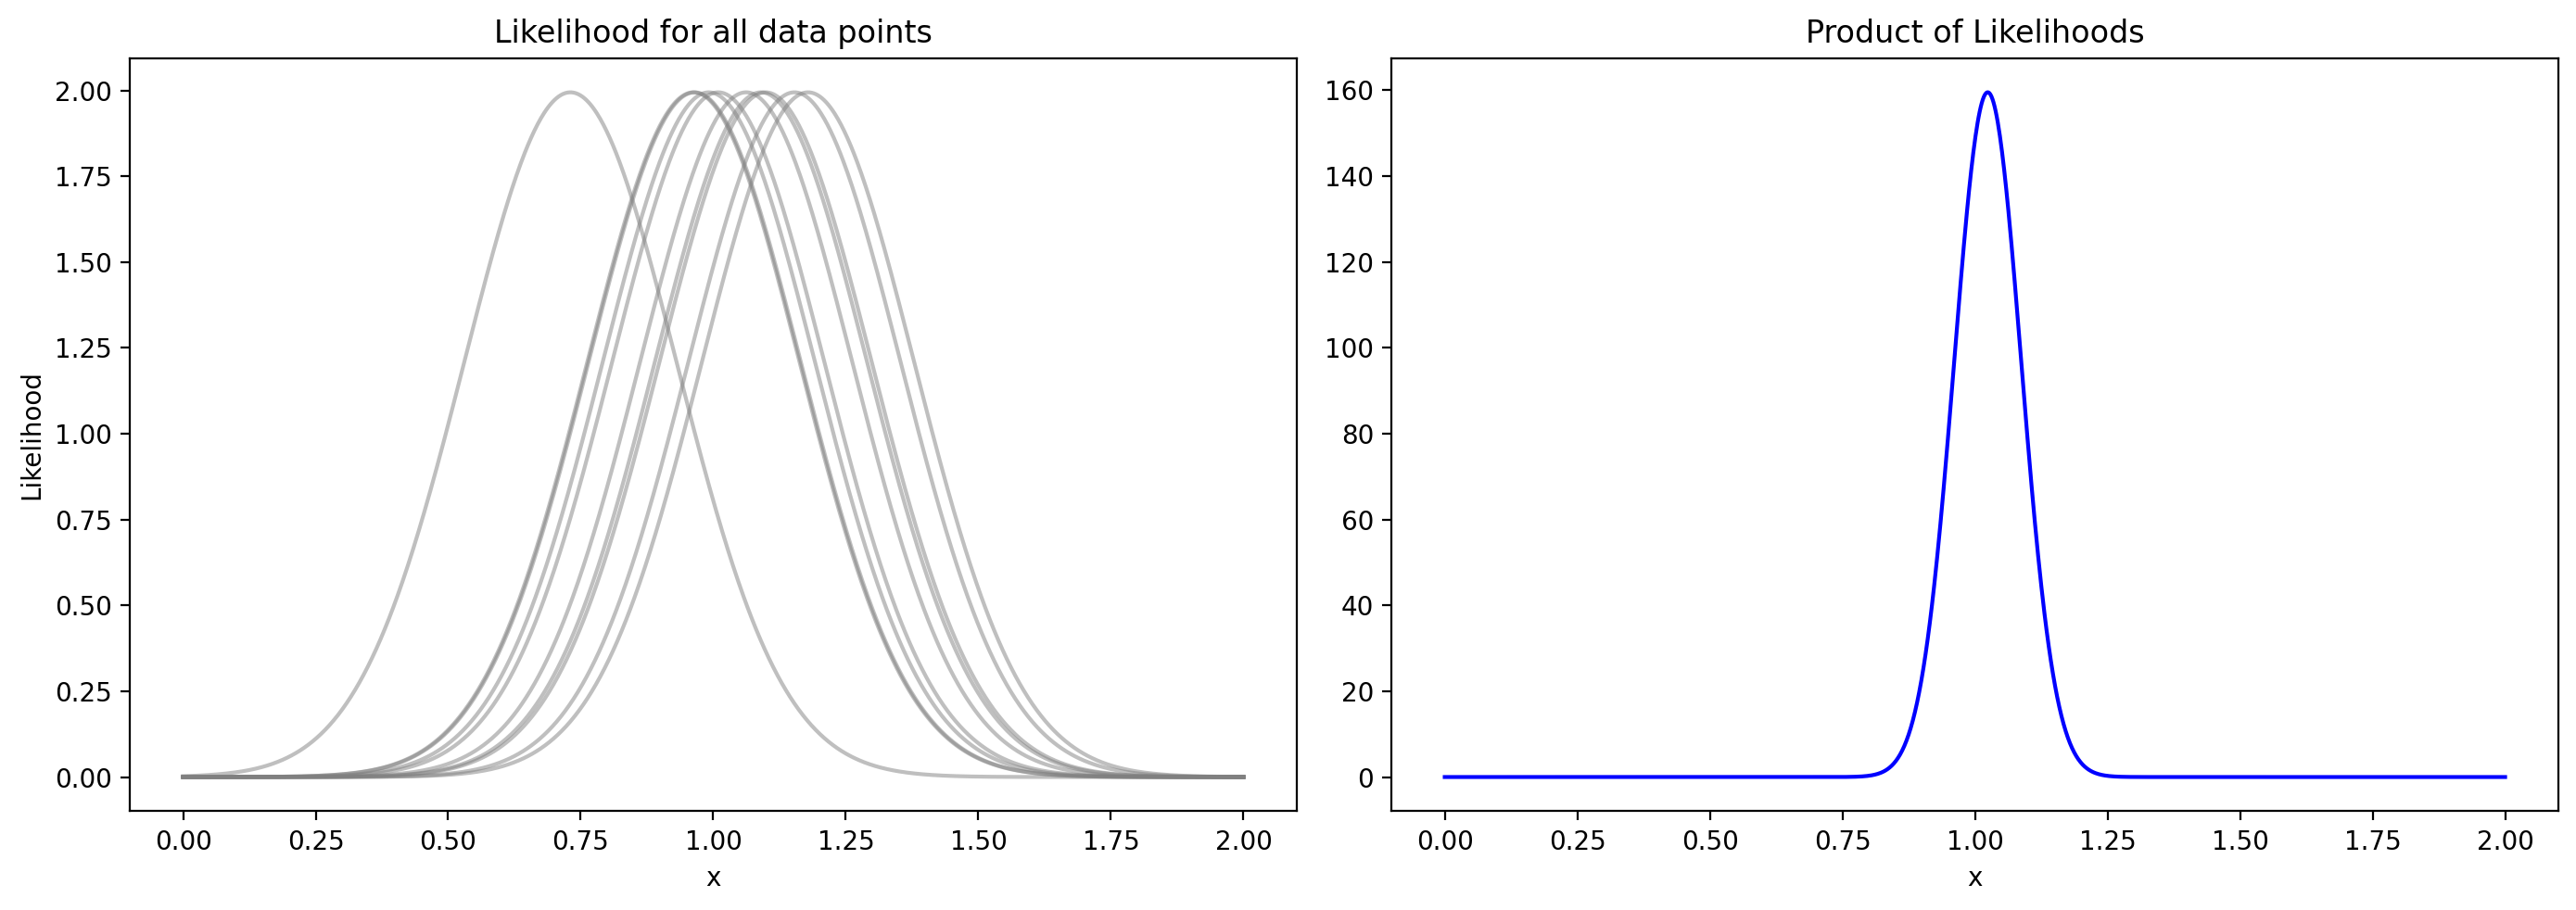

Stima MLE numerica (dal grafico): 1.0250
Stima MLE analitica (formula esatta): 1.0241


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu = 1
sigma = 0.2
N = 10

# Generate fake measurements following a normal distribution
data = np.random.normal(mu, sigma, N)
print("Dati generati:", data)

# Create a grid of x values
x = np.linspace(0, 2, 1000)
likelihoods = []

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for d in data: 
    like = norm.pdf(x, loc=d, scale=sigma)  #sample each gaussian computing the pdf for each x
    likelihoods.append(like)
    axs[0].plot(x, like, alpha=0.5, color='gray') 

axs[0].set_title('Likelihood for all data points')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Likelihood')

total_likelihood = np.prod(likelihoods, axis=0)

axs[1].plot(x, total_likelihood, color='blue')
axs[1].set_title('Product of Likelihoods')
axs[1].set_xlabel('x')

plt.tight_layout()
plt.show()

#compare MLE
mle_estimate = x[np.argmax(total_likelihood)]       # x per cui MLE è massimo
analytical_mle = np.mean(data)                      # lo stimatore MLE x gauss homosched è la mean

print(f"Stima MLE numerica (dal grafico): {mle_estimate:.4f}")
print(f"Stima MLE analitica (formula esatta): {analytical_mle:.4f}")


### Part 2

We want to verify how much precise is our estimate of the MLE computing the Fisher Information to compute the sigma relative to the MLE. \
We do it using the proper formula for the Fisher Information. Then we compare to the analitical error expected. 

Errore stimato numericamente (Fisher): 0.06325
Errore analitico atteso: 0.06325


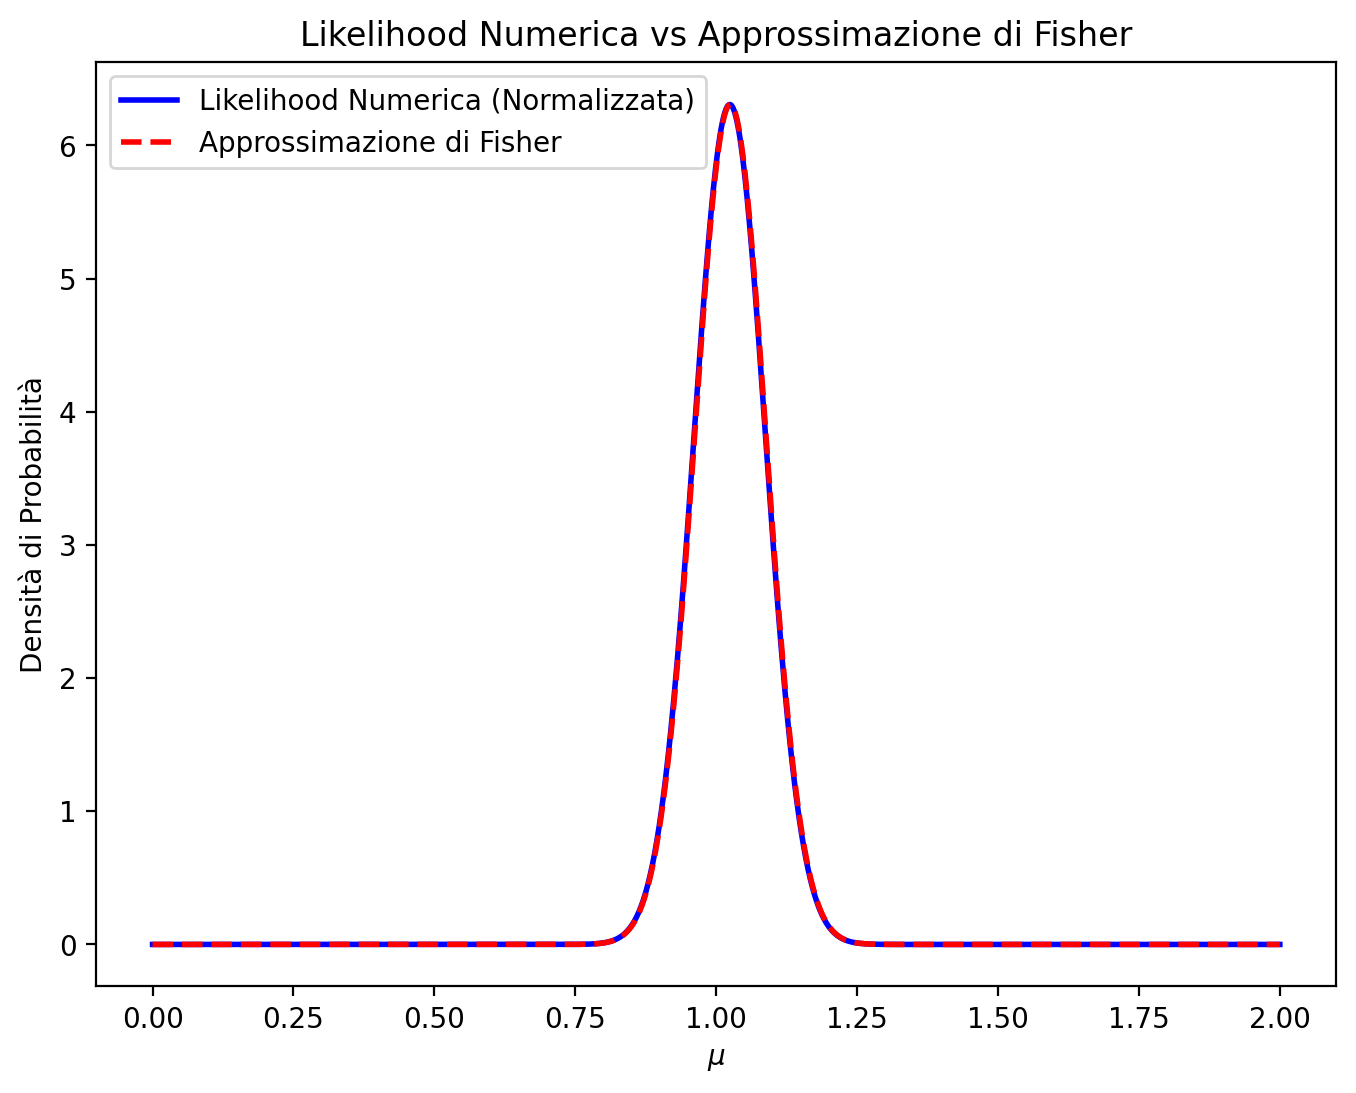

In [ ]:
'''
Do a rough second order differentation of our log-likelihood function with np.diff, normalize, multiply by, then take the square root.
Compare with the Fisher matrix error derived above
Plot a Gaussian at the measured  with this error as the scale to see if it matches the numerical likelihood distribution. 
(The normalization won't be captured, you can rescale it as you like to check it agrees)
'''

log_likelihoods = []
for d in data: 
    log_like = norm.logpdf(x, loc=d, scale=sigma)
    log_likelihoods.append(log_like)

total_log_likelihood = np.sum(log_likelihoods, axis=0)

dx = x[1] - x[0]
d2_log_like = np.diff(total_log_likelihood, n=2) / (dx**2)

# NB: due to FD derivatives at each order of derivatives we lose one element
# Solution: rescale x axis
x_diff = x[1:-1]

mle_idx = np.argmin(np.abs(x_diff - mle_estimate)) #find on x the position of mle
fisher_info = -d2_log_like[mle_idx]
fisher_error = np.sqrt(1 / fisher_info) # uncertanty on theta hat mle
analytical_error = sigma / np.sqrt(N)

print(f"Errore stimato numericamente (Fisher): {fisher_error:.5f}")
print(f"Errore analitico atteso: {analytical_error:.5f}")

#check accuracy of the method visually

plt.figure(figsize=(8, 6))
area_likelihood = np.trapz(total_likelihood, x)
plt.plot(x, total_likelihood / area_likelihood, 
         label='Likelihood Numerica (Normalizzata)', color='blue', lw=2)

fisher_gaussian = norm.pdf(x, loc=mle_estimate, scale=fisher_error)
plt.plot(x, fisher_gaussian, 
         label='Approssimazione di Fisher', color='red', linestyle='--', lw=2)

plt.title('Likelihood Numerica vs Approssimazione di Fisher')
plt.xlabel(rf'$\mu$')
plt.ylabel('Densità di Probabilità')
plt.legend()
plt.show()

### Part 3

Let's make our model more realistic. Our  measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). \
Let's assume that each measurment has a that is normally distributed with mean  and standard deviation.

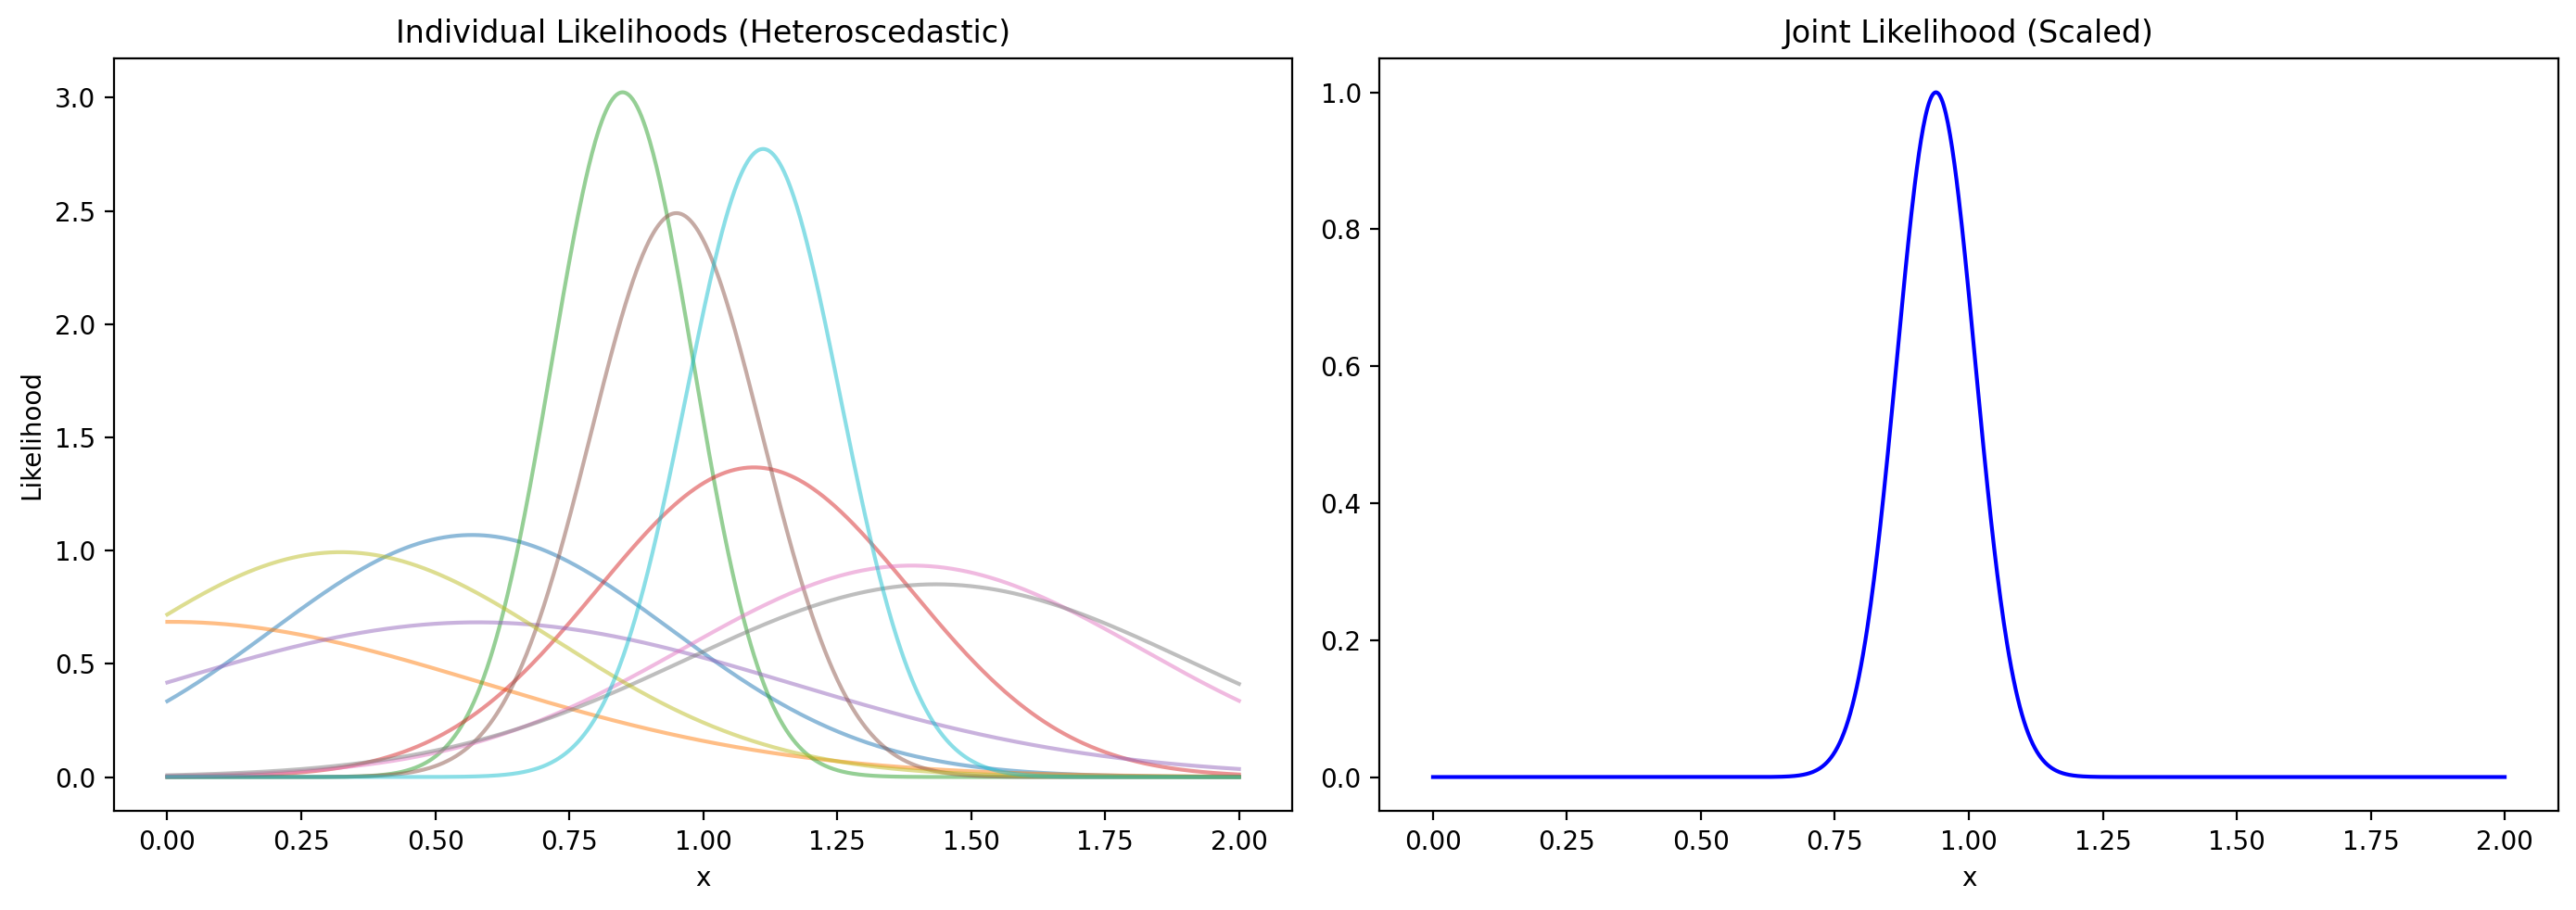

Stima MLE numerica: 0.9389
Stima MLE analitica (media pesata): 0.9386
Errore stimato numericamente (Fisher): 0.07337
Errore analitico atteso: 0.07337


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(221)
N = 10
true_mu = 1.0

sigma_het = np.random.uniform(0.1, 0.6, N)
data_het = np.random.normal(loc=true_mu, scale=sigma_het)

x = np.linspace(0, 2, 1000)
dx = x[1] - x[0]

log_likelihoods_het = []

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for d, s in zip(data_het, sigma_het):
    # compute the pdf to draw different gaussians
    like = norm.pdf(x, loc=d, scale=s)
    axs[0].plot(x, like, alpha=0.5)
    # evaluate x for each gaussian
    log_like = norm.logpdf(x, loc=d, scale=s)
    log_likelihoods_het.append(log_like)

axs[0].set_title('Individual Likelihoods (Heteroscedastic)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('Likelihood')

#build the total log like
total_log_likelihood_het = np.sum(log_likelihoods_het, axis=0)

# to draw get back the total likelihood and not ist logarithm
total_likelihood_het = np.exp(total_log_likelihood_het - np.max(total_log_likelihood_het))
axs[1].plot(x, total_likelihood_het, color='blue')
axs[1].set_title('Joint Likelihood (Scaled)')
axs[1].set_xlabel('x')

plt.tight_layout()
plt.show()

#mle estimates, analitically and numerically
mle_estimate_num = x[np.argmax(total_log_likelihood_het)]
weights = 1.0 / (sigma_het**2)
mle_estimate_ana = np.sum(data_het * weights) / np.sum(weights)

print(f"Stima MLE numerica: {mle_estimate_num:.4f}")
print(f"Stima MLE analitica (media pesata): {mle_estimate_ana:.4f}")

#mle uncertanty estimates, analitically and numerically
d2_log_like_het = np.diff(total_log_likelihood_het, n=2) / (dx**2)
x_diff = x[1:-1]

mle_idx = np.argmin(np.abs(x_diff - mle_estimate_num))
fisher_info_het = -d2_log_like_het[mle_idx]
fisher_error_num = np.sqrt(1 / fisher_info_het)

analytical_error_ana = np.sqrt(1 / np.sum(weights))

print(f"Errore stimato numericamente (Fisher): {fisher_error_num:.5f}")
print(f"Errore analitico atteso: {analytical_error_ana:.5f}")
